# Neural Network Wine Quality Model

This notebook uses the preprocessed CSV/data files created in `Preprocessing/winequiality_tuning_dataset.ipynb`.

This program:

1. Loads train and test csv.
2. Separates attributes and labels.
3. Encodes labels for multiclass classification (`softmax`).
4. Imports neural network model.
5. Compiles model and declare:
    - Loss
    - Metric
    - Learning rate
6. Trains the model.
7. Plots train vs validation behavior (accuracy & loss).
8. Makes predictions for test.
9. Calculates metrics and show them on classification report.
10. Plots confusion Matrix.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import sys
import os

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


## 2. Load preprocessed datasets

In [2]:
# Use the files generated in the Preprocessing notebook.
# If your files are named differently, only change these paths.

train_df = pd.read_csv("../../Dataset/train/preprocessed_train.csv")
test_df = pd.read_csv("../../Dataset/test/preprocessed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (3918, 12)
Test shape: (980, 12)


,alcohol,density,residual sugar,total sulfur dioxide,free sulfur dioxide,chlorides,citric acid,fixed acidity,pH,sulphates,volatile acidity,quality
0,0.811436,-1.015152,-0.396463,0.273654,0.090254,-0.876675,-0.777631,-1.476971,0.727373,-1.572934,-0.676949,7
1,1.954627,-1.633570,-0.945154,-0.762947,0.265528,-0.502390,-0.199185,-0.773832,0.465637,-0.870325,0.225769,7
2,-0.903350,0.248282,-0.376867,0.839073,1.492444,9.088661,-0.116550,-0.539453,-0.450439,-0.079891,-0.075137,5
3,0.893092,-1.477303,-1.023539,-0.998539,-0.201869,-0.455604,0.048721,-0.656643,-0.843043,2.203587,-0.576647,6
4,1.056405,-1.181394,-0.435656,-0.904302,0.090254,-0.783104,-1.438712,-1.828540,0.727373,-1.133804,0.225769,8


## 2. Separate attributes and labels

In [3]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

print("\nUnique quality scores in training set:", y_train.unique())
print(y_train.value_counts().sort_index())

print(X_train.describe())
print(X_train.mean())
print(X_train.std())


X_train: (3918, 11)
y_train: (3918,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64

Unique quality scores in training set: [7 5 6 8 4 3 9]
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64
            alcohol       density  residual sugar  total sulfur dioxide  \
count  3.918000e+03  3.918000e+03    3.918000e+03          3.918000e+03   
mean   2.434084e-09  4.868169e-09    1.168361e-08         -9.736338e-10   
std    1.000128e+00  1.000128e+00    1.000128e+00          1.000128e+00   
min   -2.046541e+00 -2.308510e+00   -1.141115e+00         -3.048182e+00   
25%   -8.216940e-01 -7.624654e-01   -9.255581e-01         -6.922700e-01   
50%   -8.678555e-02 -9.085019e-02   -2.396946e-01         -1.03

## 3. Encode labels

The wine quality labels are usually `3, 4, 5, 6, 7, 8, 9`.

For neural networks, we encode them as:

`3 → 0`, `4 → 1`, ..., `9 → 6`.


In [4]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)

print("Original classes:", encoder.classes_)
print("Number of classes:", num_classes)
print("Encoded labels example:", y_train_encoded[:10])


Original classes: [3 4 5 6 7 8 9]
Number of classes: 7
Encoded labels example: [4 4 2 3 5 3 3 2 3 4]


## 4. Import Neural network model

In [5]:
sys.path.append(os.path.abspath("../../"))

from models.neural_network_model import create_model 

model = create_model(num_classes)

model.summary()

C:\Users\mikeb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.21 KB)

 Trainable params: 311 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile model

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 6. Train model

In [7]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2760 - loss: 1.7890 - val_accuracy: 0.2985 - val_loss: 1.7750
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3162 - loss: 1.7263 - val_accuracy: 0.3342 - val_loss: 1.7173
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3481 - loss: 1.6717 - val_accuracy: 0.3750 - val_loss: 1.6673
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3787 - loss: 1.6238 - val_accuracy: 0.3980 - val_loss: 1.6237
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4040 - loss: 1.5815 - val_accuracy: 0.4260 - val_loss: 1.5846
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4199 - loss: 1.5441 - val_accuracy: 0.4298 - val_loss: 1.5503
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4320 - loss: 1.5109 - val_accuracy: 0.4337 - val_loss: 1.5198
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4378 - loss: 1.4814 - val_accuracy: 0.4426 - val_loss:

## 7. Train vs Validation behavior plots (accuracy & loss)

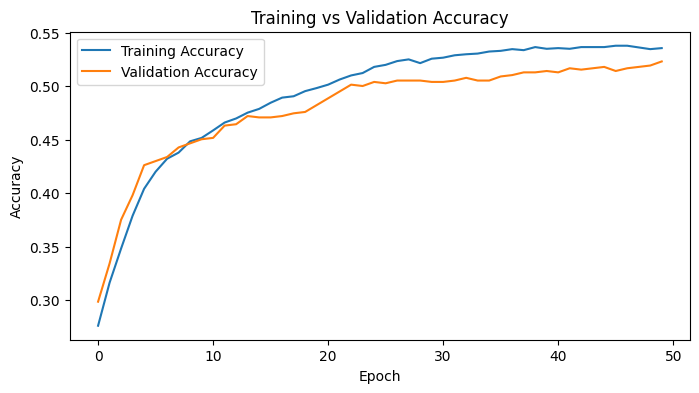

In [8]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


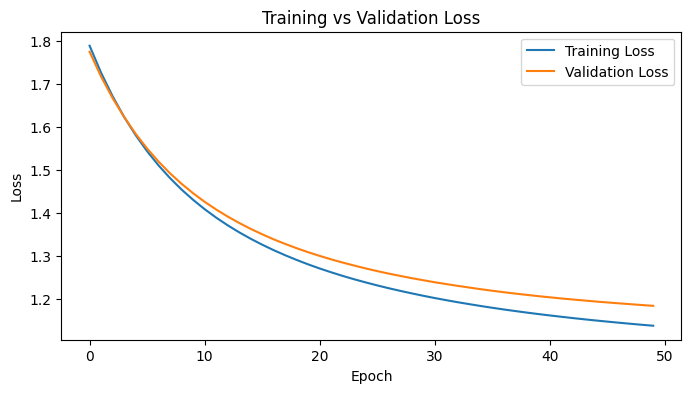

In [9]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


## 8. Predictions

In [10]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[7.7363305e-02 1.2384608e-01 4.8869660e-01 2.3640586e-01 3.0497812e-02
  3.1285338e-02 1.1905098e-02]
 [8.1557455e-03 2.1611759e-02 2.2839366e-01 6.0391879e-01 1.1620623e-01
  1.5522005e-02 6.1918446e-03]
 [1.7791147e-03 2.8830415e-02 3.7942743e-01 3.9231959e-01 1.6582286e-01
  3.1496931e-02 3.2362444e-04]
 [7.8715878e-03 1.7291905e-02 2.7833089e-01 5.3601068e-01 1.2390673e-01
  2.7549326e-02 9.0388460e-03]
 [1.3862389e-04 2.9982983e-03 6.7094197e-03 2.3669901e-01 7.0865667e-01
  4.4489998e-02 3.0791049e-04]]


## 9. Metrics calculation and classification report.

### Metrics function

In [11]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


### Metrics results

In [12]:
evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
evaluate_model(y_test_encoded, y_test_pred, "Test")


Training Results
---------------------
Accuracy : 0.5342
Precision: 0.5037
Recall   : 0.5342
F1 Score : 0.4996

Test Results
---------------------
Accuracy : 0.5378
Precision: 0.5298
Recall   : 0.5378
F1 Score : 0.5056


### Classification report

In [13]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       1.00      0.06      0.11        33
           5       0.58      0.52      0.55       291
           6       0.53      0.74      0.62       440
           7       0.48      0.27      0.35       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.54       980
   macro avg       0.37      0.23      0.23       980
weighted avg       0.53      0.54      0.51       980



## 10. Confusion matrix

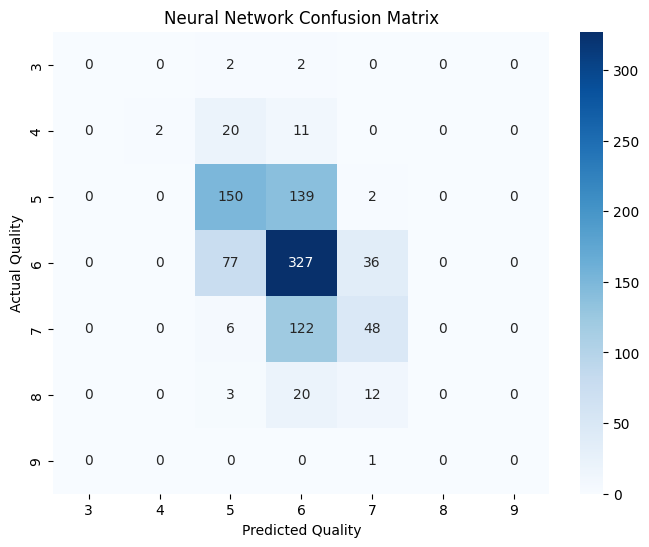

In [14]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()
